## **Agentic RAG**

* Agentic RAG enhances traditional Retrieval Augmented Generation by enabling AI agents to not only retrieve information but also decide how to use it, introducing autonomous decision making for more flexible and intelligent responses.

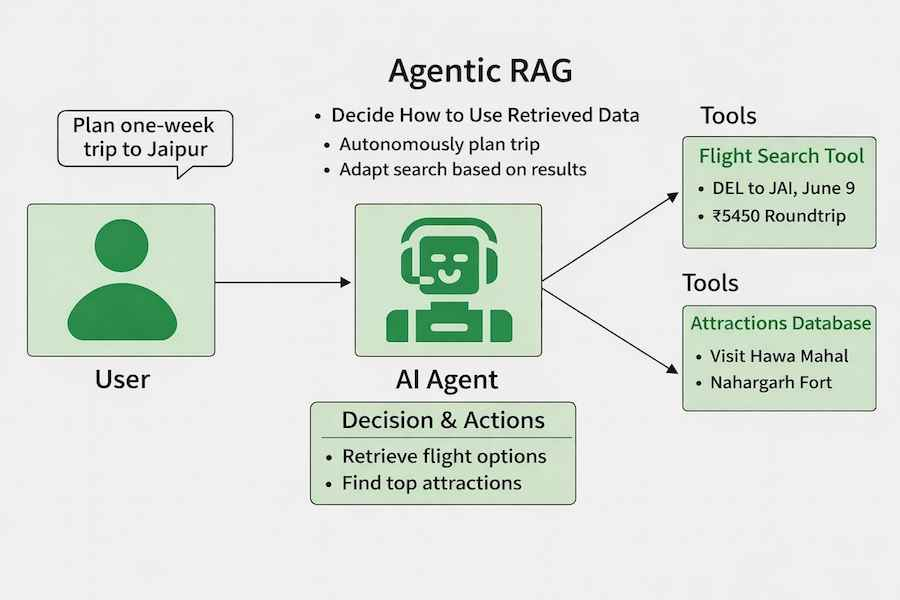

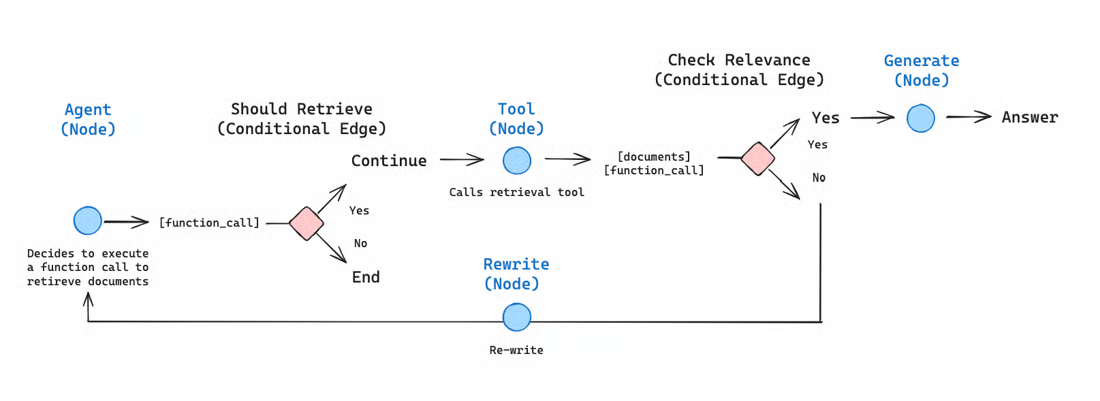

* Agentic AI: Refers to AI systems capable of autonomous decision making, adapting actions based on real time data instead of fixed instructions.
* Agents: Autonomous entities that retrieve, process and act on information, actively interacting with their environment to generate better outcomes.
* Example: An AI assistant retrieves relevant data for a query and decides how to use it to produce the most accurate and context aware response.

## **Working**

* Agentic RAG follows an intelligent, multi step process where an agent refines queries, retrieves information and validates responses for better accuracy.

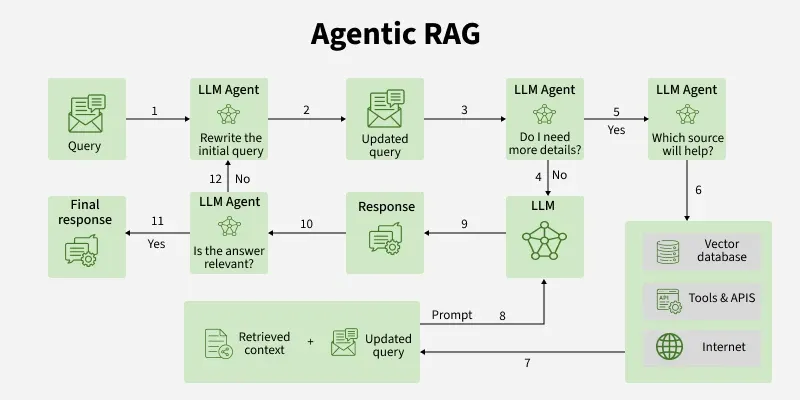

* Query Input: The user submits a query, initiating the process.
* Query Refinement: An LLM agent reviews and rewrites the query for clarity, if needed, ensuring optimal data retrieval.
* Information Sufficiency: The agent checks if further details are needed. If so, more information is gathered before proceeding.
* Source Selection: The agent determines the best source for the query vector database, APIs/tools or internet based on context.
* Data Retrieval: The chosen source is queried and relevant context is collected.
* Context Integration: Retrieved context is combined with the updated query to enrich understanding.
* Response Generation: The LLM produces a response using the enhanced context and query.
* Answer Validation: The agent verifies whether the response is relevant to the original question.
* Final Output: If validated, the system delivers a precise, context aware final response.

In [27]:
import os
import operator
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict, Literal
from IPython.display import Image, display
from typing import Annotated, List, Sequence
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

In [35]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

In [9]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [10]:
urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/', 'title': "Reward Hacking in Reinforcement Learning | Lil'Log", 'description': 'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\nWith the rise of language models generalizing to a broad spectrum of tasks and RLHF becomes a de facto method for alignment training, reward hacking in RL training of language models has become a critical practical challenge. Instances where the model learns to modify unit tests to pass coding tasks, or where responses contain biases that mimic a user’s preference, are pretty concerning and are likely one of the major blockers for real-world deployment of more autonomous use

In [11]:
# Split documents

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs_list)
doc_splits[:2] # Display first 2 docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/', 'title': "Reward Hacking in Reinforcement Learning | Lil'Log", 'description': 'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\nWith the rise of language models generalizing to a broad spectrum of tasks and RLHF becomes a de facto method for alignment training, reward hacking in RL training of language models has become a critical practical challenge. Instances where the model learns to modify unit tests to pass coding tasks, or where responses contain biases that mimic a user’s preference, are pretty concerning and are likely one of the major blockers for real-world deployment of more autonomous use 

In [12]:
print(len(doc_splits))

183


In [16]:
# Add embeddings to the vector DB
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7918.71it/s]


In [17]:
retriever = vectorstore.as_retriever()

In [18]:
retriever.invoke("When Reward hacking occurs?")

[Document(id='fe84922b-5296-484a-ae9e-cbd204169f59', metadata={'source': 'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/', 'title': "Reward Hacking in Reinforcement Learning | Lil'Log", 'description': 'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\nWith the rise of language models generalizing to a broad spectrum of tasks and RLHF becomes a de facto method for alignment training, reward hacking in RL training of language models has become a critical practical challenge. Instances where the model learns to modify unit tests to pass coding tasks, or where responses contain biases that mimic a user’s preference, are pretty concerning and are likely one of the major blockers for re

In [22]:
# Retriver to Retriver Tools - 
"""create_retriever_tool function in LangChain is used to wrap a retriever into a tool that can be 
passed to an agent for document retrieval tasks"""

from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retriever_vector_db_blog",
    description="Search and run information about LangGraph"
)

retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000024056D1FF60>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x0000024056D1FCE0>)

### **LangChin Blogs - Separate Vector Stores**

In [23]:
langchain_urls = [
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs = [WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEv

In [24]:
# Split documents
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs_list)

# Add embeddings to the vector DB
vectorstorelangchain = FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
)

langchain_retriever = vectorstorelangchain.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6432.79it/s]


In [25]:
retriever_tool_langchain = create_retriever_tool(
    retriever=langchain_retriever,
    name="retriever_vector_langchain_blog",
    description="Search and run information about LangChain"
)

retriever_tool_langchain

StructuredTool(name='retriever_vector_langchain_blog', description='Search and run information about LangChain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002405B291D00>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002405B2927A0>)

In [26]:
tools = [retriever_tool, retriever_tool_langchain]

### **LangGraph Workflow**

In [28]:
class AgentState(TypedDict):
    # The add_messages function defines how an update shoud be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [29]:
# Create nodes

def agent(state):
    """
    Invokes the agent model to generate a response based on the current state.
    Given the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("-- CALL AGENT --")
    messages = state['messages']
    model = llm.bind_tools(tools)
    response = model.invoke(messages)

    return {"messages": [response]} # Return a list, because this will get add to the existing list

In [46]:
# Edges

def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrived documents are relevant to the question.

    Args:   
        state (messages): The current state
    
    Returns:
        str: A decision for whether the documents are rlevant or not
    """

    print("-- CHECK RELEVANCE --")

    # Data model
    class grade(BaseModel):
        """binary score for relevance check"""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM with tool and validation
    llm_with_tool = llm.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question.""",

        input_variables=['context', 'question'],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state['messages']
    last_messages = messages[-1]

    question = messages[0].content
    docs = last_messages.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("--- DECISION: DOCS ARE RELEVANT ---")
        return "generate"
    else:
        print("--- DECISION: DOCS ARE NOT RELEVANT ---")
        print(score)
        return "rewrite"

In [59]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    # prompt = hub.pull(
    #     "rlm/rag-prompt",
    #     dangerously_pull_public_prompt=True,)

    prompt = PromptTemplate.from_template("""
        You are an assistant for question-answering tasks.

        Use the following retrieved context to answer the question.

        Question:
        {question}

        Context:
        {context}

        Answer:
        """)
    
    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [60]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    response = llm.invoke(msg)
    return {"messages": [response]}

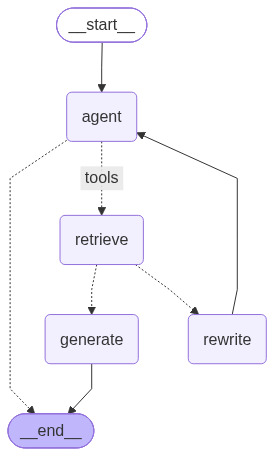

In [61]:
# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])

workflow.add_node("agent", agent)  # agent
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node("generate", generate)

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [62]:
graph.invoke({"messages":"What is Reward Function in RL?"})

-- CALL AGENT --
-- CHECK RELEVANCE --
--- DECISION: DOCS ARE RELEVANT ---
---GENERATE---


{'messages': [HumanMessage(content='What is Reward Function in RL?', additional_kwargs={}, response_metadata={}, id='bdb58550-d28e-435b-9ca4-a0e0ec1c6119'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'se2ga2npz', 'function': {'arguments': '{"query":"Reward Function in RL"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 312, 'total_tokens': 333, 'completion_time': 0.037787401, 'completion_tokens_details': None, 'prompt_time': 0.058237059, 'prompt_tokens_details': None, 'queue_time': 0.05861928, 'total_time': 0.09602446}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fac87-a309-71e3-95d4-e8f79df96b9a-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Reward Function in RL'}, 'id': 'se2ga2npz', 'type': 't

In [63]:
graph.invoke({"messages":"What is Machine learning?"})

-- CALL AGENT --
-- CHECK RELEVANCE --
--- DECISION: DOCS ARE NOT RELEVANT ---
no
---TRANSFORM QUERY---
-- CALL AGENT --


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='f8e2cbcf-fa5a-4df6-a971-e15789fbd207'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6sbp1jkvb', 'function': {'arguments': '{"query":"Machine learning definition LangGraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 310, 'total_tokens': 332, 'completion_time': 0.057179326, 'completion_tokens_details': None, 'prompt_time': 0.032769191, 'prompt_tokens_details': None, 'queue_time': 0.321847065, 'total_time': 0.089948517}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fac88-34f9-7b40-abd1-da023b22d92e-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Machine learning definition LangGraph'}, 

In [64]:
graph.invoke({"messages":"What is Langchain?"})

-- CALL AGENT --
-- CHECK RELEVANCE --
--- DECISION: DOCS ARE RELEVANT ---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='21205f01-fb57-4734-92fa-0a40f62f8fed'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4p43pdm52', 'function': {'arguments': '{"query":"What is Langchain?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 310, 'total_tokens': 332, 'completion_time': 0.035732297, 'completion_tokens_details': None, 'prompt_time': 0.017129634, 'prompt_tokens_details': None, 'queue_time': 0.058707535, 'total_time': 0.052861931}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fac88-e139-72b0-bae2-a5356b84d169-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is Langchain?'}, 'id': '4p43pdm52', 'type': 'too